# Calculate 2-point correlations as function of separation

We study **two-point correlation functions** of scalar fields on organoid surfaces.  
Each organoid is represented as a triangular mesh. Distances between vertices are computed using:

- **Heat method (Crane et al. 2013):** smooth geodesic approximation.  
- **Dijkstra (graph geodesic):** shortest path along mesh edges, used for comparison.  

To make correlations efficient:  
1. **Coarse-grain** vertices with farthest-point sampling.  
2. **Precompute distance bins** between vertex pairs.  
3. **Accumulate correlations per bin**, weighted by vertex areas.  

This yields normalized two-point functions of fields (e.g. HKS), revealing characteristic length scales of variation across the organoid surface.


In [6]:
from src.fatemarkers import FateMarkers

import matplotlib
import matplotlib.pyplot as plt
import meshplot as mplt
import plotly.graph_objects as go

import glob
import os

from nonlocal_correlations import *

## Load organoid ensemble

In [7]:
data_dir = '../NicoleData/20250714/fractal_output'

# choose one timepoint/well/round
timepoint = "day4p5"
zarr_name = "r0.zarr"
well = "B06"
round_name = "0_fused_zillum"

# directory containing the organoid meshes
mesh_dir = f"{data_dir}/{timepoint}/{zarr_name}/{well[0]}/{well[1:]}/{round_name}/meshes/nnorg_linked_annotated"

# collect all VTP files
organoid_paths = sorted(glob.glob(os.path.join(mesh_dir, "*.vtp")))

print(f"Found {len(organoid_paths)} organoids:")
for p in organoid_paths:
    print(" ", os.path.basename(p))

Found 103 organoids:
  1.vtp
  10.vtp
  101.vtp
  102.vtp
  104.vtp
  105.vtp
  106.vtp
  107.vtp
  108.vtp
  109.vtp
  11.vtp
  110.vtp
  111.vtp
  113.vtp
  114.vtp
  115.vtp
  116.vtp
  117.vtp
  118.vtp
  119.vtp
  120.vtp
  121.vtp
  123.vtp
  124.vtp
  125.vtp
  126.vtp
  127.vtp
  128.vtp
  129.vtp
  130.vtp
  14.vtp
  15.vtp
  16.vtp
  17.vtp
  18.vtp
  19.vtp
  2.vtp
  20.vtp
  21.vtp
  22.vtp
  23.vtp
  25.vtp
  26.vtp
  28.vtp
  29.vtp
  32.vtp
  34.vtp
  35.vtp
  36.vtp
  38.vtp
  4.vtp
  40.vtp
  41.vtp
  42.vtp
  44.vtp
  45.vtp
  46.vtp
  47.vtp
  48.vtp
  49.vtp
  5.vtp
  51.vtp
  52.vtp
  53.vtp
  54.vtp
  55.vtp
  56.vtp
  57.vtp
  58.vtp
  59.vtp
  6.vtp
  60.vtp
  61.vtp
  62.vtp
  63.vtp
  64.vtp
  65.vtp
  66.vtp
  67.vtp
  69.vtp
  71.vtp
  72.vtp
  73.vtp
  75.vtp
  76.vtp
  77.vtp
  78.vtp
  8.vtp
  80.vtp
  81.vtp
  82.vtp
  86.vtp
  87.vtp
  88.vtp
  89.vtp
  9.vtp
  91.vtp
  93.vtp
  94.vtp
  95.vtp
  97.vtp
  98.vtp
  99.vtp


In [8]:
Cw_raw_all = []
Ce_raw_all = []
Cw_cell_all = []
Ce_cell_all = []
bins_dist_weighted_all = []

Nw_raw_all = []
Ne_raw_all = []
Nw_cell_all = []
Ne_cell_all = []
pair_counts_all = []

coeffs_all = []

tot_area_all = []
tot_volume_all = []
num_cell_all = []

dmax = 20
nbins = 64
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])


for path in organoid_paths:
    print(f"Processing {path}")

    # Process mesh
    m = FateMarkers()
    m.load_mesh_from_file(path)
    m.align_with_pca()
    _, coeffs_fields = m.compute_coefficients(lmax=15)
    L, M = build_cotangent_laplacian_and_mass(m.v, m.f)

    _, patch_centers = get_patch_centers(m.v, m.fields[:,0])
    vertex_areas = np.array(M.diagonal())

    volume = mesh_volume_from_triangles(m.v, m.f)

    # Process fields
    hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=False)
    coeffs_hks = m.compute_hks_for_new_times(new_ts=[4.0], coeffs=True)

    vertex_fields = np.concatenate([hks, m.fields[:,3::2]], axis=1)
    _, cell_areas, cell_weighted_fields, _, _ = per_cell_stats_from_vertex_labels(m.v, m.f, vertex_areas, m.fields[:,0], vertex_fields)
    vertex_fields = vertex_fields[patch_centers, :]

    # Process geodesics
    dist_heat = heat_geodesic_all_sources(m.v, m.f, L, M, t=None, sources=patch_centers)  # (S,V)
    dist_heat = dist_heat[:, patch_centers] # (S,S)

    bins_dist_weighted = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=True)
    bins_dist_equal = pair_bins_from_distances(dist_heat, cell_areas, bin_edges, use_area_weights=False)


    # Compute correlations
    Cw_raw, Nw_raw = accumulate_correlations_from_bins(bins_dist_weighted, vertex_fields) # compute surface area weighted correlations
    Ce_raw, Ne_raw = accumulate_correlations_from_bins(bins_dist_equal, vertex_fields) # compute equal weighted correlations

    Cw_cell, Nw_cell = accumulate_correlations_from_bins(bins_dist_weighted, cell_weighted_fields) # compute surface area weighted correlations
    Ce_cell, Ne_cell = accumulate_correlations_from_bins(bins_dist_equal, cell_weighted_fields) # compute equal weighted correlations

    # compute pair counts per bin (number of stored pairs) for diagnostics
    counts_weighted = np.array([len(bins_dist_weighted[f'I_{b}']) for b in range(len(bin_edges)-1)])

    # store everything
    Cw_raw_all.append(Cw_raw)
    Ce_raw_all.append(Ce_raw)
    Cw_cell_all.append(Cw_cell)
    Ce_cell_all.append(Ce_cell)
    Nw_raw_all.append(Nw_raw)
    Ne_raw_all.append(Ne_raw)
    Nw_cell_all.append(Nw_cell)
    Ne_cell_all.append(Ne_cell)
    bins_dist_weighted_all.append(bins_dist_weighted)
    pair_counts_all.append(counts_weighted)
    coeffs_all.append(np.concatenate([coeffs_hks, coeffs_fields[:,3::2]], axis=1) )
    tot_area_all.append( np.sum(vertex_areas) )
    tot_volume_all.append( volume )
    num_cell_all.append( cell_areas.shape[0])  
    

Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum/meshes/nnorg_linked_annotated/1.vtp


heat sources: 100%|██████████| 499/499 [00:05<00:00, 97.10it/s] 


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum/meshes/nnorg_linked_annotated/10.vtp


heat sources: 100%|██████████| 262/262 [00:02<00:00, 118.71it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum/meshes/nnorg_linked_annotated/101.vtp


...

heat sources: 100%|██████████| 104/104 [00:00<00:00, 110.89it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum/meshes/nnorg_linked_annotated/98.vtp


heat sources: 100%|██████████| 312/312 [00:02<00:00, 112.03it/s]


Processing ../NicoleData/20250714/fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum/meshes/nnorg_linked_annotated/99.vtp


heat sources: 100%|██████████| 53/53 [00:00<00:00, 110.40it/s]


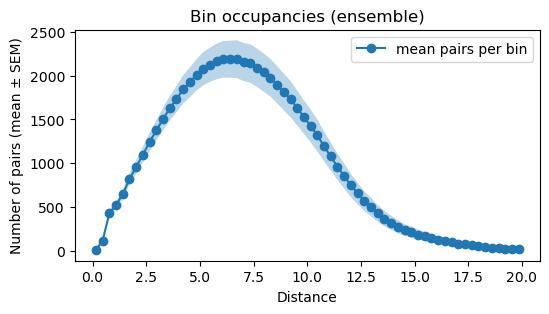

In [9]:
pair_counts_arr = np.stack(pair_counts_all, axis=0)  # (n_org, B)
mean_counts = pair_counts_arr.mean(axis=0)
std_counts = pair_counts_arr.std(axis=0, ddof=1)
sem_counts = std_counts / np.sqrt(pair_counts_arr.shape[0])

plt.figure(figsize=(6,3))
plt.plot(bin_centers, mean_counts, 'o-', label='mean pairs per bin')
plt.fill_between(bin_centers, mean_counts - sem_counts, mean_counts + sem_counts, alpha=0.3)
plt.xlabel("Distance")
plt.ylabel("Number of pairs (mean ± SEM)")
plt.title("Bin occupancies (ensemble)")
plt.legend()
plt.show()


In [ ]:
# convert lists -> arrays with shape (n_org, B, F, F)
arr_Cw_raw = np.stack(Cw_raw_all, axis=0)    # (n_org, B, F, F)
arr_Ce_raw = np.stack(Ce_raw_all, axis=0)
arr_Cw_cell = np.stack(Cw_cell_all, axis=0)
arr_Ce_cell = np.stack(Ce_cell_all, axis=0)

# number of organoids
n_org = arr_Cw_raw.shape[0]

# ensemble mean (ignore NaNs from empty bins)
mean_Cw_raw = np.nanmean(arr_Cw_raw, axis=0)    # (B,F,F)
mean_Ce_raw = np.nanmean(arr_Ce_raw, axis=0)    # (B,F,F)
mean_Cw_cell = np.nanmean(arr_Cw_cell, axis=0)    # (B,F,F)
mean_Ce_cell = np.nanmean(arr_Ce_cell, axis=0)    # (B,F,F)

In [11]:
import scikits.bootstrap as boot

# Each array has shape (n_org, B, F, F)
corr_dict = {
    "Cw_raw":  np.stack(Cw_raw_all, axis=0),
    "Ce_raw":  np.stack(Ce_raw_all, axis=0),
    "Cw_cell": np.stack(Cw_cell_all, axis=0),
    "Ce_cell": np.stack(Ce_cell_all, axis=0),
}

# Pick which field indices you want to analyze, e.g. autocorr of field 0
i, j = 0, 0   # change as needed

# Store results
ci_results = {}

for name, arr in corr_dict.items():
    # extract data across organoids for this (i,j) field pair
    # shape: (n_org, B) → transpose to (B, n_org)
    data = arr[:, :, i, j].T

    ci_low = []
    ci_high = []
    for b in range(data.shape[0]):
        ci = boot.ci(
            data[b], 
            statfunction=np.nanmean, 
            method='bca', 
            alpha=0.05, 
            n_samples=2000
        )
        ci_low.append(ci[0])
        ci_high.append(ci[1])

    ci_results[name] = {
        "low": np.array(ci_low),
        "high": np.array(ci_high)
    }

/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/ipykernel_88618/1607167683.py:25: InstabilityWarning: Some values used top 10 low/high samples; results may be unstable.
  ci = boot.ci(
/tmp/i

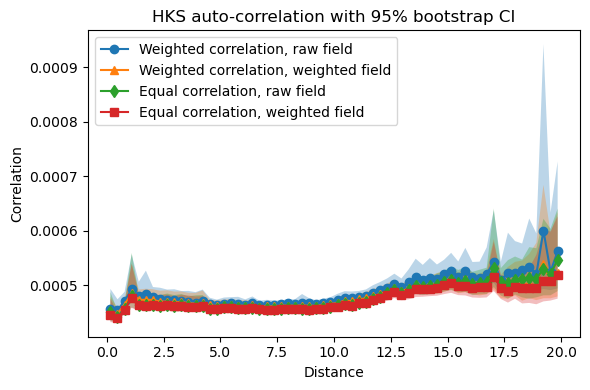

In [12]:
plt.figure(figsize=(6,4))

# Weighted, raw field
mean_Cw_raw = np.nanmean(corr_dict["Cw_raw"], axis=0)  # (B,F,F)
plt.plot(bin_centers, mean_Cw_raw[:,0,0], 'o-', label="Weighted correlation, raw field")
plt.fill_between(
    bin_centers,
    ci_results["Cw_raw"]["low"],
    ci_results["Cw_raw"]["high"],
    alpha=0.3
)

# Weighted, cell-weighted field
mean_Cw_cell = np.nanmean(corr_dict["Cw_cell"], axis=0)
plt.plot(bin_centers, mean_Cw_cell[:,0,0], '^-', label="Weighted correlation, weighted field")
plt.fill_between(
    bin_centers,
    ci_results["Cw_cell"]["low"],
    ci_results["Cw_cell"]["high"],
    alpha=0.3
)

# Equal, raw field
mean_Ce_raw = np.nanmean(corr_dict["Ce_raw"], axis=0)
plt.plot(bin_centers, mean_Ce_raw[:,0,0], 'd-', label="Equal correlation, raw field")
plt.fill_between(
    bin_centers,
    ci_results["Ce_raw"]["low"],
    ci_results["Ce_raw"]["high"],
    alpha=0.3
)

# Equal, cell-weighted field
mean_Ce_cell = np.nanmean(corr_dict["Ce_cell"], axis=0)
plt.plot(bin_centers, mean_Ce_cell[:,0,0], 's-', label="Equal correlation, weighted field")
plt.fill_between(
    bin_centers,
    ci_results["Ce_cell"]["low"],
    ci_results["Ce_cell"]["high"],
    alpha=0.3
)

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation with 95% bootstrap CI")
plt.legend()
plt.tight_layout()
plt.show()


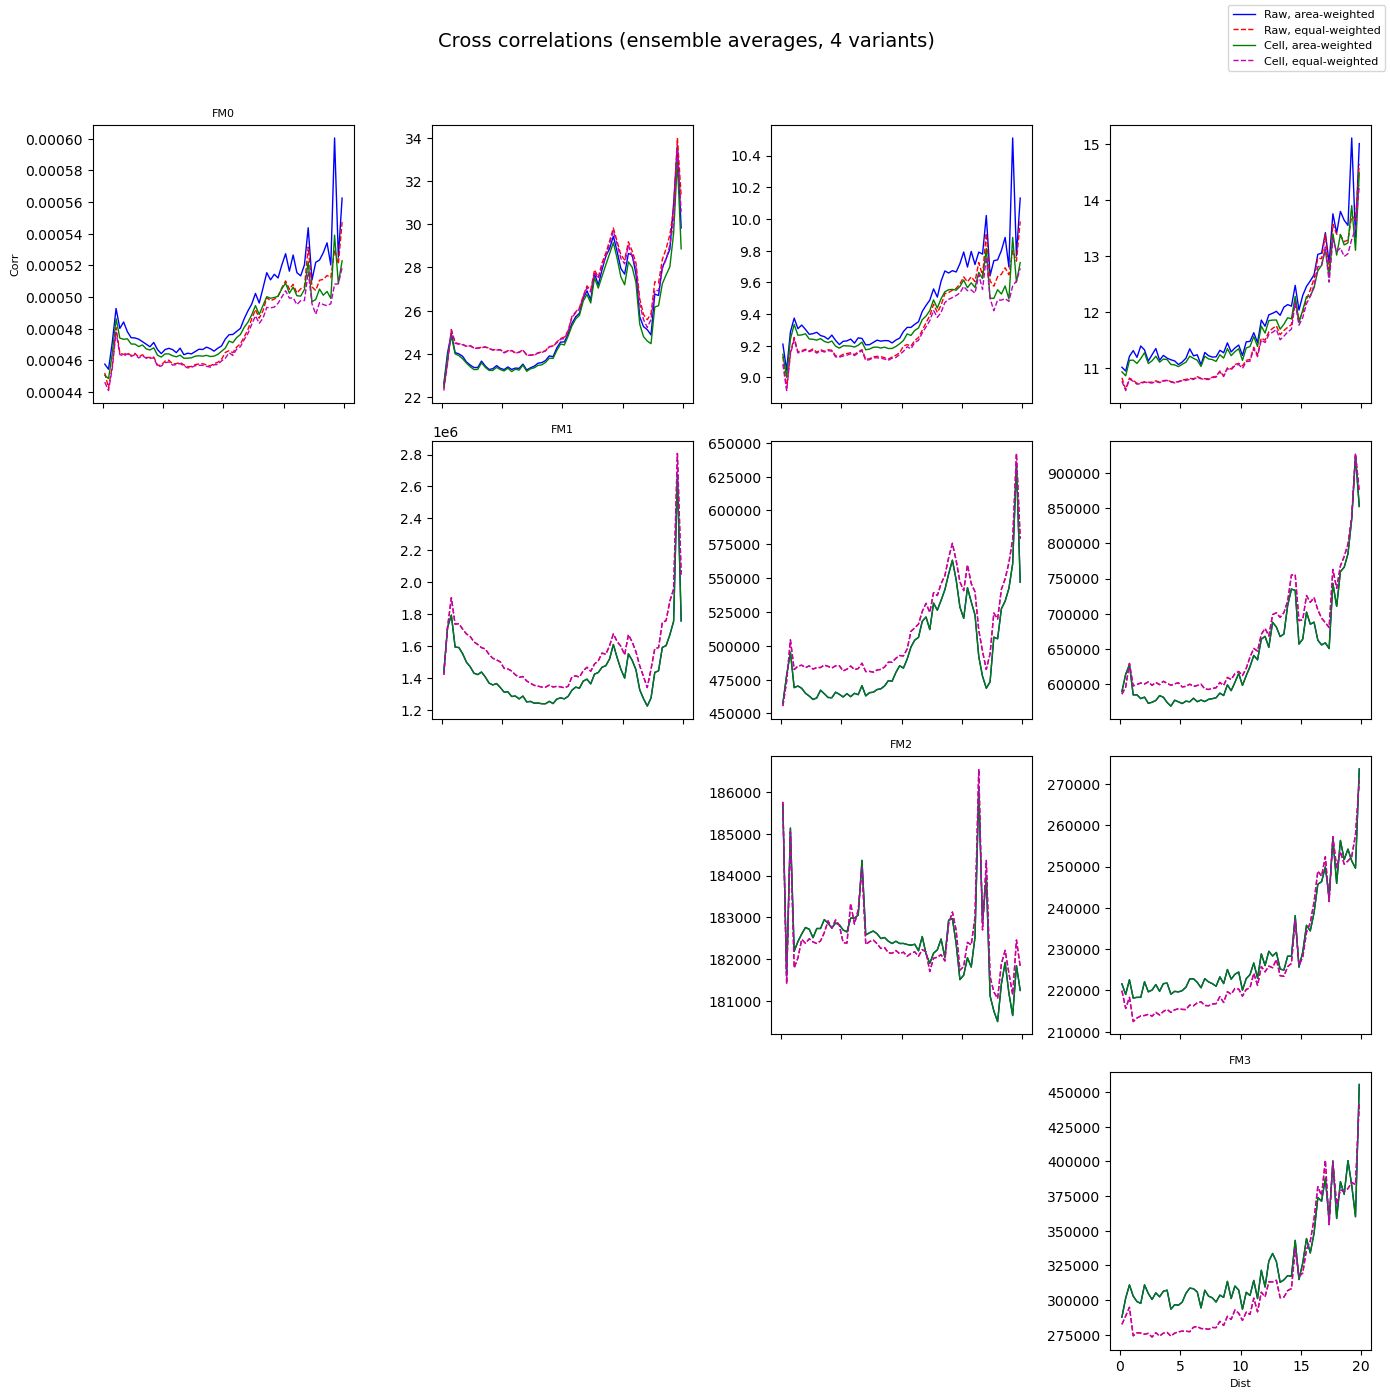

In [13]:
n_org, B, F, _ = arr_Cw_raw.shape
field_names = [f"FM{i}" for i in range(F)]

fig, axes = plt.subplots(F, F, figsize=(14, 14), sharex=True, sharey=False)

for i in range(F):
    for j in range(F):
        ax = axes[i, j]

        if i > j:
            ax.axis("off")  # hide lower triangle
            continue

        # Plot the four variants
        ax.plot(bin_centers, mean_Cw_raw[:, i, j],  'b-',  lw=1,
                label="Raw, area-weighted" if (i==0 and j==0) else "")
        ax.plot(bin_centers, mean_Ce_raw[:, i, j],  'r--', lw=1,
                label="Raw, equal-weighted" if (i==0 and j==0) else "")
        ax.plot(bin_centers, mean_Cw_cell[:, i, j], 'g-',  lw=1,
                label="Cell, area-weighted" if (i==0 and j==0) else "")
        ax.plot(bin_centers, mean_Ce_cell[:, i, j], 'm--', lw=1,
                label="Cell, equal-weighted" if (i==0 and j==0) else "")

        # Label diagonals with field names
        if i == j:
            ax.set_title(field_names[i], fontsize=8)

        # Only left column gets y-labels
        if j == 0:
            ax.set_ylabel("Corr", fontsize=8)

        # Only bottom row gets x-labels
        if i == F-1:
            ax.set_xlabel("Dist", fontsize=8)

# Global labels + legend
fig.suptitle("Cross correlations (ensemble averages, 4 variants)", fontsize=14)
fig.legend(loc="upper right", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [14]:
def zero_low_l_modes(coeffs, l_cut):
    """
    Zero out coefficients for modes with spherical-harmonic band index ell <= l_cut.
    coeffs: (K, F)
    returns: coeffs_clean (K, F)
    """
    K, F = coeffs.shape
    coeffs_clean = coeffs.copy()
    # modes m with ell satisfying ell^2 <= m <= (ell+1)^2 - 1 for ell = 0..l_cut inclusive
    max_m = min(K, (l_cut+1)**2)  # upper bound (exclusive)
    if max_m <= 0:
        return coeffs_clean
    coeffs_clean[:max_m, :] = 0.0
    return coeffs_clean

def compute_mode_power_from_coeffs(coeffs):
    """
    coeffs: (K, F)
    returns: mode_power: (K, F, F) where mode_power[m] = outer(coeffs[m], coeffs[m])
    """
    K, F = coeffs.shape
    mode_power = np.empty((K, F, F), dtype=float)
    for m in range(K):
        cm = coeffs[m]
        mode_power[m] = np.outer(cm, cm)
    return mode_power

def band_power_from_mode_power_lband(mode_power):
    """
    Group mode_power (K,F,F) into l-bands using indices m in [l^2, (l+1)^2)
    returns:
      bands_idx : np.array of ell indices (0..Lmax-1)
      S_bands : array (Lmax, F, F) with summed power per band
    """
    K = mode_power.shape[0]
    Lmax = int(np.floor(np.sqrt(K)))
    S_bands = []
    bands_idx = []
    for ell in range(Lmax):
        i0 = ell*ell
        i1 = min((ell+1)*(ell+1), K)
        if i1 <= i0:
            continue
        S = mode_power[i0:i1].sum(axis=0)   # sum over modes in band
        S_bands.append(S)
        bands_idx.append(ell)
    S_bands = np.stack(S_bands, axis=0)  # (L_used, F, F)
    return np.array(bands_idx), S_bands

In [15]:
l_cut = 1   # remove bands with ell <= 2 (i.e. ell=0,1,2). Tune this.
all_band_spectra_orig = []
all_band_spectra_clean = []
power_removed_fraction = []  # per organoid diagnostic

for coeffs in coeffs_all:
    K, F = coeffs.shape

    # original mode power
    mode_power_orig = compute_mode_power_from_coeffs(coeffs)   # (K, F, F)
    bands_idx, S_bands_orig = band_power_from_mode_power_lband(mode_power_orig)  # (L, F, F)
    all_band_spectra_orig.append(S_bands_orig)

    # zero low-l modes and recompute
    coeffs_clean = zero_low_l_modes(coeffs, l_cut)
    mode_power_clean = compute_mode_power_from_coeffs(coeffs_clean)
    _, S_bands_clean = band_power_from_mode_power_lband(mode_power_clean)
    all_band_spectra_clean.append(S_bands_clean)

    # diagnostic: fraction of total power removed (auto-power summed over fields)
    total_power_orig = np.nansum(S_bands_orig)   # sum over bands and all field pairs
    total_power_clean = np.nansum(S_bands_clean)
    frac_removed = (total_power_orig - total_power_clean) / (total_power_orig + 1e-30)
    power_removed_fraction.append(frac_removed)

all_band_spectra_orig = np.stack(all_band_spectra_orig, axis=0)   # (n_org, L, F, F)
all_band_spectra_clean = np.stack(all_band_spectra_clean, axis=0)
mean_orig = np.nanmean(all_band_spectra_orig, axis=0)   # (L, F, F)
mean_clean = np.nanmean(all_band_spectra_clean, axis=0)

print("Mean fraction of power removed (per organoid):", np.mean(power_removed_fraction))

Mean fraction of power removed (per organoid): 0.9708105785670853


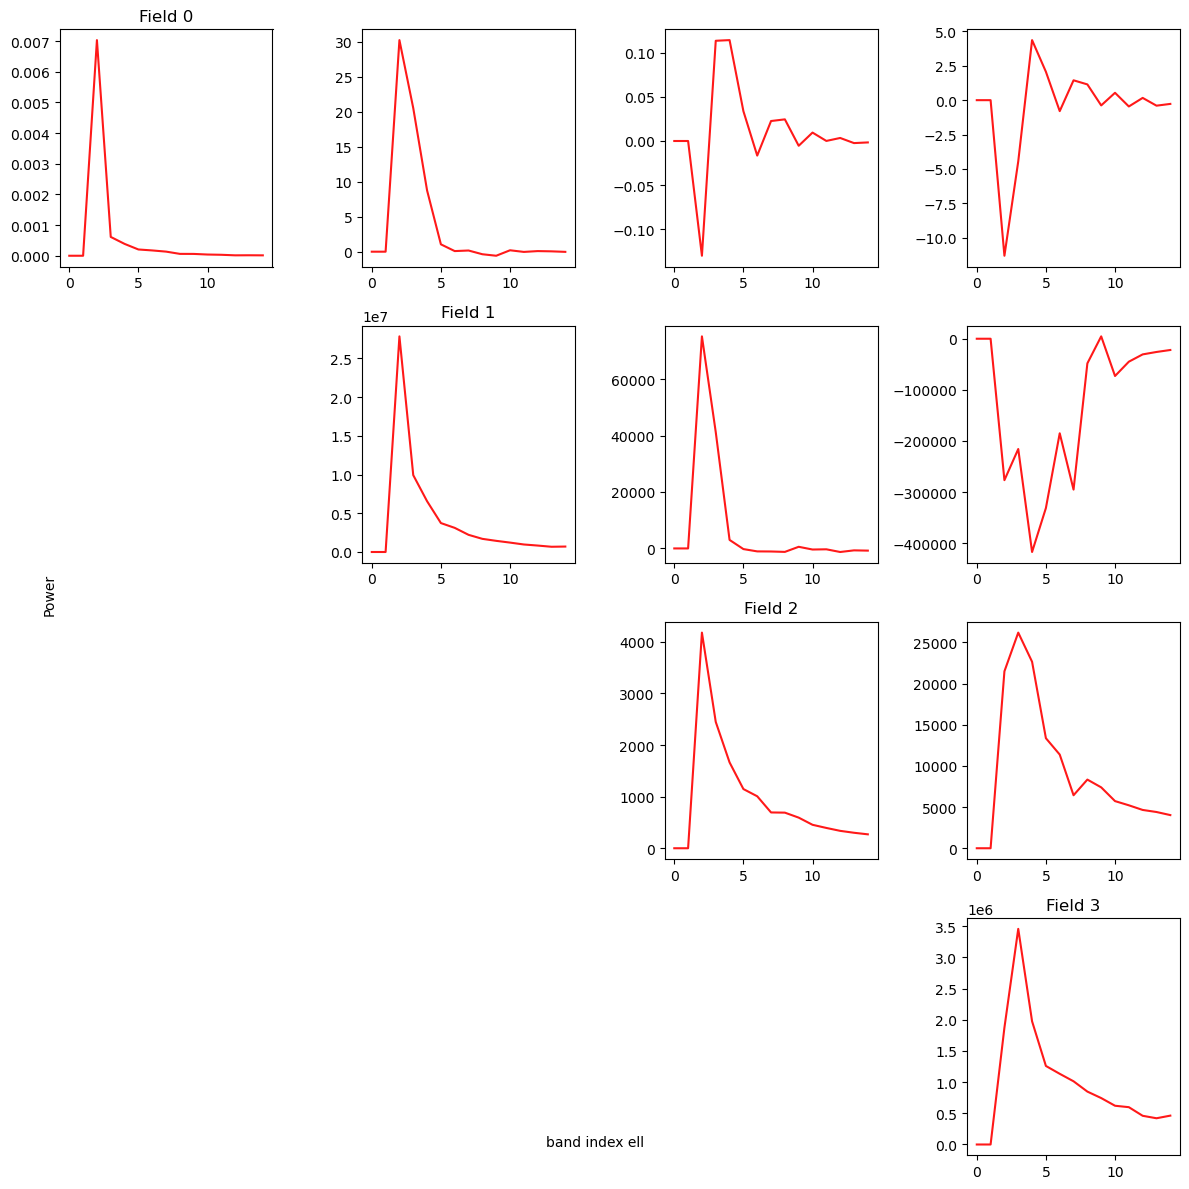

In [16]:
# ----------------- quick plotting: original vs cleaned mean spectra -----------------
L = mean_orig.shape[0]
k_axis = bands_idx   # integers ell

F = mean_orig.shape[1]
fig, axes = plt.subplots(F, F, figsize=(12, 12))
for i in range(F):
    for j in range(F):
        ax = axes[i, j]
        if i > j:
            ax.axis('off'); continue
        # ax.plot(k_axis, mean_orig[:, i, j], '-k', label='orig', alpha=0.6)
        ax.plot(k_axis, mean_clean[:, i, j], '-r', label='low-l removed', alpha=0.9)
        if i == j:
            ax.set_title(f"Field {i}")
# global labels
fig.text(0.5,0.04,'band index ell', ha='center')
fig.text(0.04,0.5,'Power', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

## Group organoids

If the organoids do not develop any protrusions, i.e. they are sphere-like, they will likely show different correlation behavior. Hence it may be worth exploring whether we need to calculate correlations across groups, rather than days. 

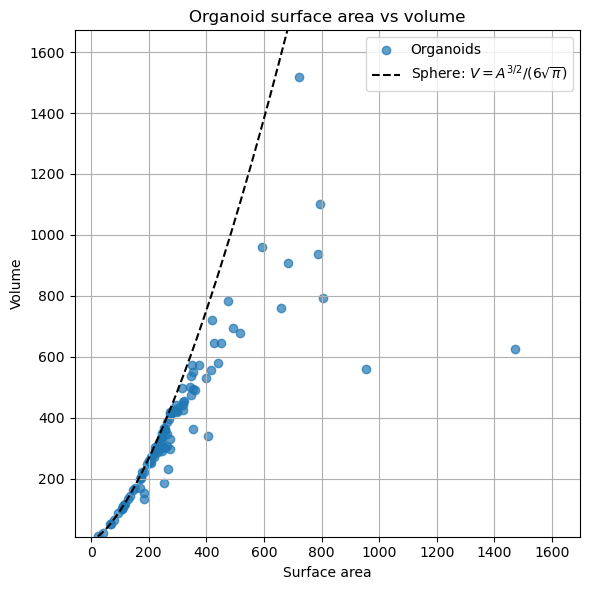

In [17]:
tot_area_all = np.stack(tot_area_all, axis=0)
tot_volume_all = np.stack(tot_volume_all, axis=0)

plt.figure(figsize=(6,6))
plt.scatter(tot_area_all, tot_volume_all, alpha=0.7, label="Organoids")

# Reference curve: sphere relation
A_range = np.linspace(tot_area_all.min()*0.9, tot_area_all.max()*1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)

plt.plot(A_range, V_sphere, 'k--', label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

plt.xlabel("Surface area")
plt.ylabel("Volume")
plt.title("Organoid surface area vs volume")
plt.legend()
plt.grid(True)

plt.ylim(tot_volume_all.min()*0.9, tot_volume_all.max()*1.1)
plt.tight_layout()

plt.show()



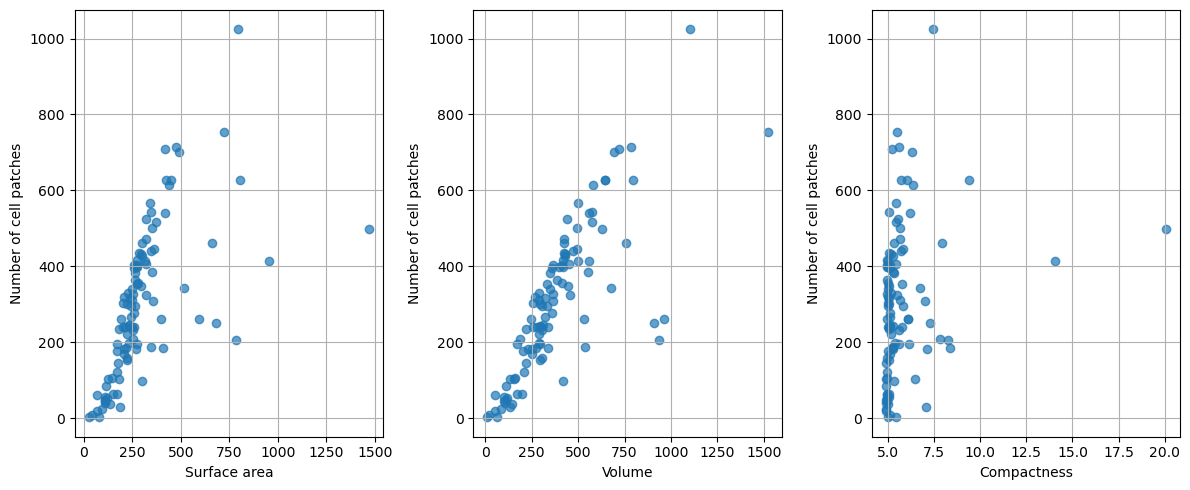

In [26]:
num_cells = np.stack(num_cell_all, axis=0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.scatter(tot_area_all, num_cells, alpha=0.7)
plt.xlabel("Surface area")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(tot_volume_all, num_cells, alpha=0.7)
plt.xlabel("Volume")
plt.ylabel("Number of cell patches")
plt.grid(True)


plt.subplot(1,3,3)
plt.scatter(tot_area_all / (tot_volume_all ** (2.0/3.0)), num_cells, alpha=0.7)
plt.xlabel("Compactness")
plt.ylabel("Number of cell patches")
plt.grid(True)

plt.tight_layout()

plt.show()

In [18]:
compactness = tot_area_all / (tot_volume_all ** (2.0/3.0))

comp_sphere = 4.835
threshold = 1.15 * comp_sphere   # 20% larger than sphere
group_sphere_like = (compactness <= threshold) & (tot_volume_all >= 100)
group_protruded   = (compactness > threshold) & (tot_volume_all >= 100)

print(np.sum(group_sphere_like))
print(np.sum(group_protruded))

62
33


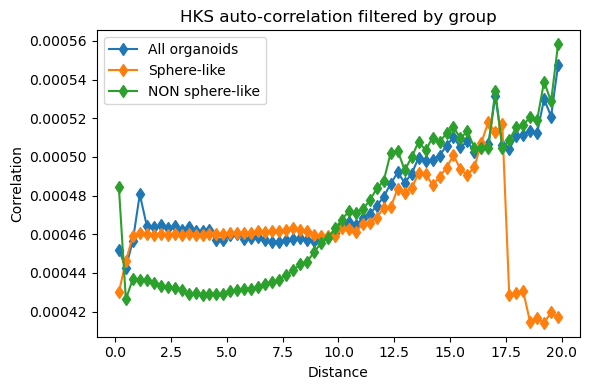

In [19]:
mean_Ce_raw_sphere = np.nanmean(arr_Ce_raw[group_sphere_like], axis=0)    # (B,F,F)
mean_Ce_raw_protruded = np.nanmean(arr_Ce_raw[group_protruded], axis=0)    # (B,F,F)

plt.figure(figsize=(6,4))
# Equal, raw field
plt.plot(bin_centers, mean_Ce_raw[:,0,0], 'd-', label="All organoids")
plt.plot(bin_centers, mean_Ce_raw_sphere[:,0,0], 'd-', label="Sphere-like")
plt.plot(bin_centers, mean_Ce_raw_protruded[:,0,0], 'd-', label="NON sphere-like")

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("HKS auto-correlation filtered by group")
plt.legend()
plt.tight_layout()
plt.show()

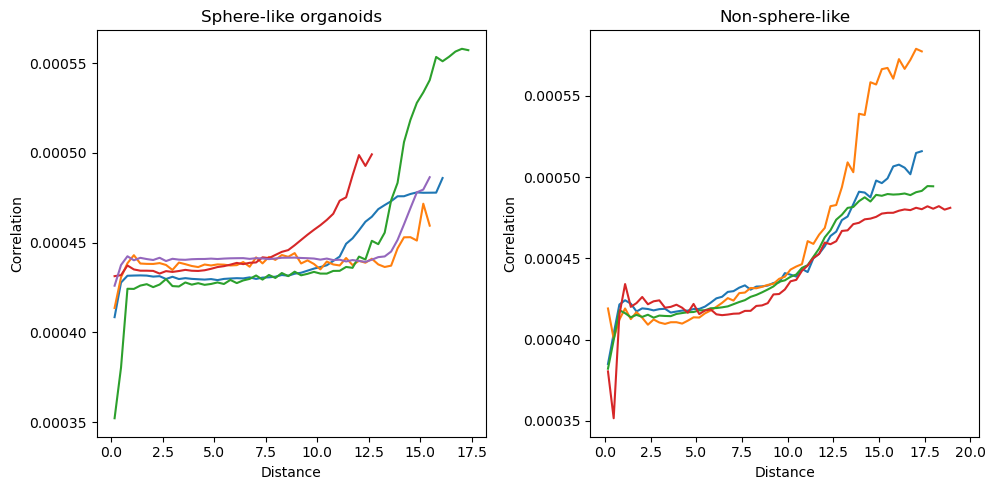

In [28]:
# Get orgnaoids with similar colume from the two groups
vol_min = 450
vol_max = 550

group_sph_vol = (compactness <= threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)
group_pro_vol   = (compactness > threshold) & (tot_volume_all >= vol_min) & (tot_volume_all <= vol_max)


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(bin_centers, arr_Ce_raw[group_sph_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Sphere-like organoids")


plt.subplot(1,2,2)
plt.plot(bin_centers, arr_Ce_raw[group_pro_vol,:,0,0].T)
plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Non-sphere-like")

plt.tight_layout()
plt.show()
